# Ball on incline experiment

href to the webpage here

## Import packages and data 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost
from scipy import stats

c:\Users\adamo\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
#import csv files
data1 = np.loadtxt('pendulum_data/Adam1.dat', delimiter='\t')
data2 = np.loadtxt('pendulum_data/Amalie_2.dat', delimiter='\t')
data3 = np.loadtxt('pendulum_data/giuia.dat', delimiter='\t')
data4 = np.loadtxt('pendulum_data/Matilde.dat', delimiter='\t')
data5 = np.loadtxt('pendulum_data/timer_output_Marta_last_take.dat', delimiter='\t')
data3[15:,0] -= 1

In [4]:
Laser_measurent = np.array([22.15,22.151,22.152,22.151,22.145])     # m
Laser_err = 0.001
dist_f_p = np.array([56.,55.9,55.5,56.5,55.6])/1000                 # m
dist_f_p_err = 0.5/1000
h_p  = np.array([25.0,25.0,25.0,24.1,24.9])/1000                    # m
h_p_err = 0.5/1000

tape_measurement = np.array([22.099,22.101,22.099,22.102,22.102])   # m
tape_err = np.array([0.002,0.001,0.001,0.005,0.002])



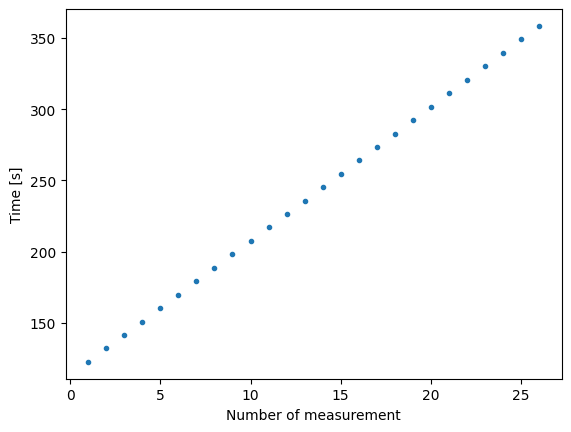

In [5]:
n_max = 26
# plt.ylim(0,26)
plt.plot(data1[:n_max,0], data1[:n_max,1], '.')
# plt.title('Direction 1')
plt.xlabel('Number of measurement')
plt.ylabel('Time [s]')
plt.show()

## Define nescesary functions

In [6]:
def model(t, a, t0):
    return a * t + t0

## Plots

### Slope/Period

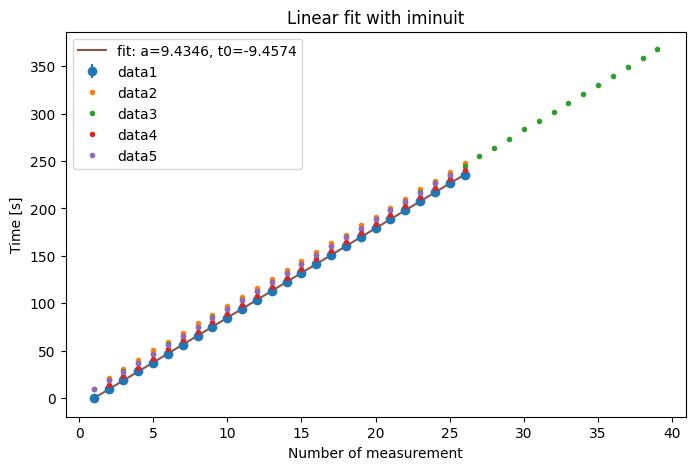

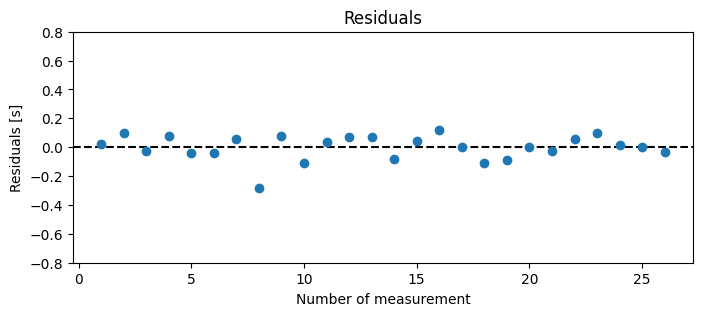

In [22]:

# Fit data1[:n_max] with iminuit using the defined model(t, a, t0)

# Prepare data
x = data1[:n_max, 0]
y = data1[:n_max, 1] - data1[0,1]
sigma = np.ones_like(y)  # equal weights; replace with measurement uncertainties when available



x2, y2 = data2[:25, 0], data2[:25, 1]
x3, y3 = data3[:, 0], data3[:, 1]
x4, y4 = data4[:, 0], data4[:, 1]
x5, y5 = data5[:, 0], data5[:, 1]

a_guess = (y[-1] - y[0]) / (x[-1] - x[0])
t0_guess = y[0] - a_guess * x[0]

def fit_data(x, y, sigma):
    # Define LeastSquares cost for iminuit
    ls = cost.LeastSquares(x, y, sigma, model)

    # Good initial guesses from the endpoints
    a_guess = (y[-1] - y[0]) / (x[-1] - x[0])
    t0_guess = y[0] - a_guess * x[0]

    m = Minuit(ls, a=a_guess, t0=t0_guess)
    m.errordef = 1.0  # appropriate for least-squares

    # Run the minimizer and estimate errors
    m.migrad()
    m.hesse()

    # Print fit results
    # print("Fit results:")
    # for name in m.parameters:
        # print(f"  {name} = {m.values[name]:.6f} ± {m.errors[name]:.6f}")

    chi2 = m.fval
    dof = len(y) - m.nfit
    redchi2 = chi2 / dof
    p_value = stats.chi2.sf(chi2, dof)

    # print(f"\nchi2 = {chi2:.4f}")
    # print(f"dof = {dof}")
    # print(f"reduced chi2 = {redchi2:.4f}")
    # print(f"p-value = {p_value:.4f}")

    # Covariance matrix (as a 2x2 numpy array)
    try:
        cov = m.covariance
        # print("\nCovariance matrix:")
        # print(cov)
    except Exception:
        pass
    return m, redchi2, p_value

m, redchi2, p_value = fit_data(x,y,sigma)
m2,  redchi22, p_value2 = fit_data(x2,y2, np.ones_like(x2))
m3,  redchi23, p_value3 = fit_data(x3,y3, np.ones_like(x3))
m4,  redchi24, p_value4 = fit_data(x4,y4, np.ones_like(x4))
m5,  redchi25, p_value5 = fit_data(x5,y5, np.ones_like(x5))

# Plot data with the fitted model
plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=sigma, fmt='o', label='data1')
plt.errorbar(data2[1:n_max,0], data2[1:n_max,1], fmt='.', label='data2')
plt.errorbar(data3[:,0], data3[:,1], fmt='.', label='data3')
plt.errorbar(data4[:,0], data4[:,1], fmt='.', label='data4')
plt.errorbar(data5[:,0], data5[:,1], fmt='.', label='data5')
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = model(x_fit, m.values['a'], m.values['t0'])
plt.plot(x_fit, y_fit, '-', label=f"fit: a={m.values['a']:.4f}, t0={m.values['t0']:.4f}")
plt.xlabel('Number of measurement')
plt.ylabel('Time [s]')
plt.title('Linear fit with iminuit')
plt.legend()
plt.show()

# Plot residuals
residuals = y - model(x, m.values['a'], m.values['t0'])
plt.figure(figsize=(8, 3))
plt.axhline(0, color='k', ls='--')
plt.ylim(-0.8, 0.8)
plt.plot(x, residuals, 'o')
# plt.plot(x2, y2 - model(x2, m2.values['a'], m2.values['t0']), 'o')
# plt.plot(x3, y3 - model(x3, m3.values['a'], m3.values['t0']), 'o')
# plt.plot(x4, y4 - model(x4, m4.values['a'], m4.values['t0']), 'o')
# plt.plot(x5, y5 - model(x5, m5.values['a'], m5.values['t0']), 'o')
plt.xlabel('Number of measurement')
plt.ylabel('Residuals [s]')
plt.title('Residuals')
plt.show()


In [8]:
#finding uncertainty as standard deviation of residuals
residuals = y - model(x, m.values['a'], m.values['t0'])
residuals = np.concatenate((residuals, y2 - model(x2, m2.values['a'], m2.values['t0'])))
residuals = np.concatenate((residuals, y3 - model(x3, m3.values['a'], m3.values['t0'])))
residuals = np.concatenate((residuals, y4 - model(x4, m4.values['a'], m4.values['t0'])))
residuals = np.concatenate((residuals, y5 - model(x5, m5.values['a'], m5.values['t0'])))

residuals1 = y - model(x, m.values['a'], m.values['t0'])
residuals2 = y2 - model(x2, m2.values['a'], m2.values['t0'])
residuals3 = y3 - model(x3, m3.values['a'], m3.values['t0'])
residuals4 = y4 - model(x4, m4.values['a'], m4.values['t0'])
residuals5 = y5 - model(x5, m5.values['a'], m5.values['t0'])

# plt.plot(residuals)
uncertainty = np.std(residuals)
print(f"Estimated uncertainty from residuals: {uncertainty:.6f} s")

uncertainty1 = np.std(residuals1)
uncertainty2 = np.std(residuals2)
uncertainty3 = np.std(residuals3)
uncertainty4 = np.std(residuals4)
uncertainty5 = np.std(residuals5)
print(f'err1 = {uncertainty1:.3f}')
print(f'err2 = {uncertainty2:.3f}')
print(f'err3 = {uncertainty3:.3f}')
print(f'err4 = {uncertainty4:.3f}')
print(f'err5 = {uncertainty5:.3f}')

Estimated uncertainty from residuals: 0.227536 s
err1 = 0.085
err2 = 0.277
err3 = 0.295
err4 = 0.260
err5 = 0.050


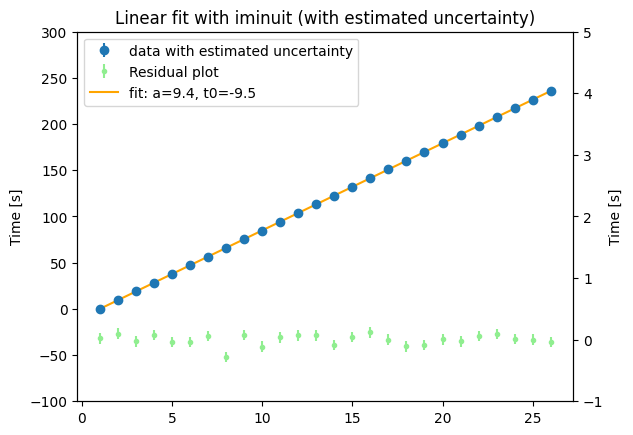

In [9]:
#redo the fit with this uncertainty
ls = cost.LeastSquares(x, y, np.ones_like(y)*uncertainty1, model)
m = Minuit(ls, a=a_guess, t0=t0_guess)
# m.errordef = 1.0  # appropriate for least-squares
m.migrad()


fig, ax = plt.subplots()
twin = ax.twinx()
p1= ax.errorbar(x, y, yerr=np.ones_like(y)*uncertainty1, fmt='o', label='data with estimated uncertainty')
# residual plot in same figure with own axis
residuals1 = y - model(x, m.values['a'], m.values['t0'])
p2 = twin.errorbar(x, residuals1, yerr=np.ones_like(y)*uncertainty1, fmt='.', color= 'lightgreen', label= 'Residual plot')
p3 =ax.plot(x_fit, y_fit, '-', label=f"fit: a={m.values['a']:.1f}, t0={m.values['t0']:.1f}", color= 'orange')
ax.set_ylim(-100,300)
twin.set_ylim(-1,5)
plt.xlabel('Number of measurement')
ax.set_ylabel('Time [s]')
twin.set_ylabel('Time [s]')
plt.title('Linear fit with iminuit (with estimated uncertainty)')
ax.legend(handles=[p1, p2, p3[0]])

plt.show()

0.00± 0.09


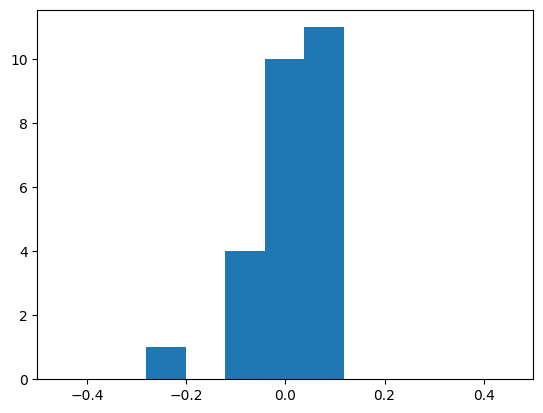

In [10]:
plt.hist(residuals1, bins= int(np.sqrt(len(residuals1))))
plt.xlim(-0.5, 0.5)
print(f'{np.mean(residuals1):.2f}± {uncertainty1:.2f}')

In [11]:
# # Define a Gaussian model
# def gaussian(x, amplitude, mean, sigma):
#     return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# # Create histogram of residuals
# counts, bins, _ = plt.hist(residuals, bins=int(np.sqrt(len(residuals))), density=True, alpha=0.7, edgecolor='black')
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # Initial guesses for Gaussian parameters
# amp_guess = np.max(counts)
# mean_guess = np.mean(residuals)
# sigma_guess = np.std(residuals)

# # Fit Gaussian using iminuit
# ls_gauss = cost.LeastSquares(bin_centers, counts, np.sqrt(counts), gaussian)
# m_gauss = Minuit(ls_gauss, amplitude=amp_guess, mean=mean_guess, sigma=sigma_guess)
# m_gauss.errordef = 1.0
# m_gauss.migrad()

# # Plot the fitted Gaussian
# x_gauss = np.linspace(residuals.min(), residuals.max(), 200)
# y_gauss = gaussian(x_gauss, m_gauss.values['amplitude'], m_gauss.values['mean'], m_gauss.values['sigma'])
# plt.plot(x_gauss, y_gauss, 'r-', linewidth=2, label=f"Gaussian fit: μ={m_gauss.values['mean']:.2f}, σ={m_gauss.values['sigma']:.2f}")
# plt.errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='o', label='Histogram data')
# plt.xlim(-0.5, 0.5)
# plt.xlabel('Residuals [s]')
# plt.ylabel('Density')
# plt.legend()
# plt.show()

# # Print fit results
# print("Gaussian fit results:")
# for name in m_gauss.parameters:
#     print(f"  {name} = {m_gauss.values[name]:.6f} ± {m_gauss.errors[name]:.6f}")


Average T: 9.4340 ± 0.0011


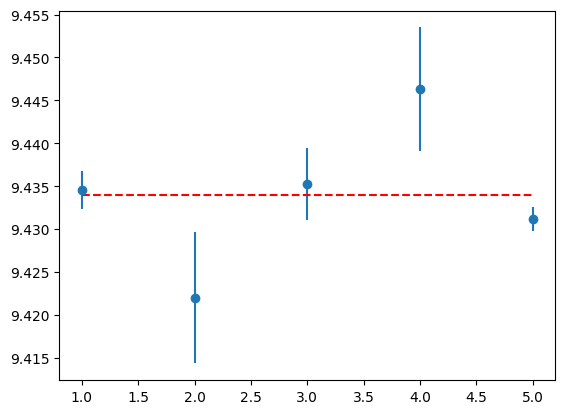

In [12]:
# a with unertainty for a data set
m1, redchi21, p_value1 =  fit_data(x , y, np.ones_like(x )*uncertainty1)
m2,  redchi22, p_value2 = fit_data(x2,y2, np.ones_like(x2)*uncertainty2)
m3,  redchi23, p_value3 = fit_data(x3,y3, np.ones_like(x3)*uncertainty3)
m4,  redchi24, p_value4 = fit_data(x4,y4, np.ones_like(x4)*uncertainty4)
m5,  redchi25, p_value5 = fit_data(x5,y5, np.ones_like(x5)*uncertainty5)

a = np.array([m1.values['a'], m2.values['a'], m3.values['a'], m4.values['a'], m5.values['a']])
a_err = np.array([m1.errors['a'], m2.errors['a'], m3.errors['a'], m4.errors['a'], m5.errors['a']])

plt.errorbar(range(1,6), a, yerr=a_err, fmt='o')
plt.plot([1,5], [np.average(a,weights=a_err), np.average(a,weights=a_err)], 'r--', label='Mean a')

# accumulate errors (quadrature sum)
a_err_accum = np.sqrt(1.0/np.sum(1.0/np.square(a_err)))

# print(f'Accumulated a error (quadrature) = {a_err_accum:.6f}')

print(f'Average T: {np.average(a,weights=a_err):.4f} ± {np.mean(a_err_accum):.4f}')

### Lengths

In [13]:
# correct laser to the top of the pendulum
laser_corr = Laser_measurent - dist_f_p + h_p/2
laser_corr_err = np.sqrt(Laser_err**2 + dist_f_p_err**2 +h_p_err**2/4)
tape_measurement = tape_measurement + h_p/2

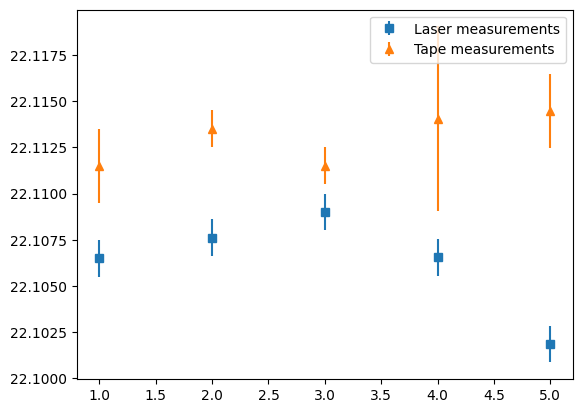

L = 22.1087 ± 0.0011 m


In [14]:
# length measurements averaged
plt.errorbar([1,2,3,4,5], laser_corr, yerr=Laser_err, fmt='s', label='Laser measurements')
plt.errorbar([1,2,3,4,5], tape_measurement, yerr=tape_err, fmt='^', label='Tape measurements')
plt.legend()
plt.show()

# print(np.average(laser_corr), np.std(laser_corr)/np.sqrt(len(laser_corr)))
# print(np.average(tape_measurement, weights=tape_err ), np.std(tape_measurement)/np.sqrt(len(tape_measurement)))
# length = np.average(tape_measurement, weights= tape_err)
length = np.average(np.array([np.average(laser_corr),np.average(tape_measurement,weights=tape_err)]), weights= np.array([np.std(laser_corr)/np.sqrt(len(laser_corr)), np.std(tape_measurement)/np.sqrt(len(tape_measurement))]))
length_err = np.sqrt(np.square(np.std(laser_corr)/np.sqrt(len(laser_corr)) +  np.square(np.std(tape_measurement)/np.sqrt(len(tape_measurement)))))
print(f'L = {length:.4f} ± {length_err:.4f} m')



In [15]:
def model_lin(x, a):
    return np.ones_like(x)*a

ls_l = cost.LeastSquares(np.arange(len(laser_corr)), laser_corr, laser_corr_err, model_lin)



m = Minuit(ls_l, a=length)
# m.errordef = 1.0  # appropriate for least-squares

# Run the minimizer and estimate errors
m.migrad()
m.hesse()

print(m.fval)
print(stats.chi2.sf(m.fval,1))

22.007619047604173
2.715702870028974e-06


In [16]:
# Do error propegation on the formula g = L*(2*np.pi/a)^2 
g = length * (2 * np.pi / np.average(a,weights=a_err))**2
# partial derivatives
dg_da = -2 * length * (2 * np.pi)**2 / (np.average(a,weights=a_err)**3)
dg_dL = (2 * np.pi / np.average(a,weights=a_err))**2
g_err = np.sqrt( (dg_da * np.mean(a_err))**2 + (dg_dL * length_err)**2 )
print(f'g = {g:.4f} ± {g_err:.4f} m/s²')

g = 9.8070 ± 0.0094 m/s²
